In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

This project analyzes college women's basketball stats and attempts to predict whether or not a player will get drafted into the WNBA. However, rather than simple counting stats like total points or total rebounds, I decided to use per-minute stats such as points per minute, rebounds per minute, and so on.

## Part 1: Cleaning the Data

In [47]:
#Loading in data
df_stats = pd.read_csv("data/stats_26.csv")

In [49]:
#Filtering to only include power conferences
conferences = ["ACC", "BIG-12", "BIG10", "Big East", "SEC"]
df_stats = df_stats[df_stats["Conference"].isin(conferences)]

In [50]:
#Setting player names to the index
df_stats = df_stats.set_index(df_stats.columns[0])

In [51]:
#Only including draft-eligible players (remember, women's basketball players almost always play all 4 years in college before declaring
#for the draft)
years = ["SR", "GR"]
df_stats = df_stats[df_stats["Year"].isin(years)]

In [52]:
#Only including variables of interest
df_stats = df_stats[["Drafted?", "POS", "MPG", "A/TO", "TS%", "2PVAL", "3PVAL", "USG%", "PP40", "ORP40", "RP40", "AP40", "SP40", "BP40", "FP40", "TP40"]]


Here are the variables I decided to use:

* Drafted?: Determines whether or not the player was drafted in the 2026 WNBA draft
* POS: Position
* MPG: Minutes per game
* A/TO: Assist/turnover ratio; if a player has 0 turnovers, it is 2x the total number of assists
* TS%: True shooting percentage, calculated as: PTS/(2 * (FGA + .44 * FTA))
* 2PVAL: One of my engineered variables, meant to calculate per-minute effectiveness on 2-point field goals: 2PM/(30 + 2PA) * (strength of competition score; 1.2 for power conferences) * 40/MIN * 2PA/GP
* 3PVAL: Similar to 2PVAL, except 2PM and 2PA are replaced with 3PM and 3PA, respectively.
* USG%: Usage rate, calculating how often a player records a statistic compared to the rest of the team. 20% is always average, since there are always 5 players on the floor at a time.
* PP40: Points per 40 minutes * 1.2 (for power conferences)
* ORP40: Offensive rebounds per 40 minutes * 1.2 (for power conferences)
* RP40: Rebounds per 40 minutes * 1.2 (for power conferences)
* AP40: Assists per 40 minutes * 1.2 (for power conferences)
* SP40: Steals per 40 minutes * 1.2 (for power conferences)
* BP40: Blocks per 40 minutes * 1.2 (for power conferences)
* FP40: Fouls per 40 minutes * 1.2 (for power conferences)
* TP40: Turnovers per 40 minutes * 1.2 (for power conferences)

In [53]:
#Replacing Y and N with 1 and 0, respectively
df_stats.replace({'Y': 1, 'N': 0}, inplace=True)
df_stats.head()

/var/folders/s2/pcwbcsfd6px_q2f9yp2rxhhw0000gn/T/ipykernel_39561/70208480.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_stats.replace({'Y': 1, 'N': 0}, inplace=True)


,Drafted?,POS,MPG,A/TO,TS%,2PVAL,3PVAL,USG%,PP40,ORP40,RP40,AP40,SP40,BP40,FP40,TP40
Player,,,,,,,,,,,,,,,,
Lauren Betts,1,C,27.7,1.43,0.602,0.328,0.000,32.1,29.6,6.0,15.2,5.5,1.8,3.6,2.5,3.2
Olivia Miles,1,G,35.4,1.77,0.593,0.169,0.060,30.1,26.5,0.7,9.7,9.0,2.4,0.4,2.3,4.2
Shay Ciezki,0,G,35.5,0.90,0.647,0.233,0.095,27.6,30.9,0.3,5.2,4.1,2.1,0.2,2.7,3.9
Kiki Rice,1,G,30.8,2.57,0.609,0.154,0.028,25.0,23.3,2.3,9.2,6.7,2.3,0.6,2.3,2.2
Raegan Beers,0,C,24.7,0.99,0.632,0.327,0.005,30.2,30.6,6.6,20.1,4.3,1.7,2.0,4.2,3.7


In [54]:
#Creating dummy variables for the POS variable
dummies = pd.get_dummies(df_stats['POS'], dtype=int)

df_stats = pd.concat([df_stats, dummies], axis=1)
df_stats

,Drafted?,POS,MPG,A/TO,TS%,2PVAL,3PVAL,USG%,PP40,ORP40,...,AP40,SP40,BP40,FP40,TP40,C,F,F-C,G,G-F
Player,,,,,,,,,,,,,,,,,,,,,
Lauren Betts,1,C,27.7,1.43,0.602,0.328,0.000,32.1,29.6,6.0,...,5.5,1.8,3.6,2.5,3.2,1,0,0,0,0
Olivia Miles,1,G,35.4,1.77,0.593,0.169,0.060,30.1,26.5,0.7,...,9.0,2.4,0.4,2.3,4.2,0,0,0,1,0
Shay Ciezki,0,G,35.5,0.90,0.647,0.233,0.095,27.6,30.9,0.3,...,4.1,2.1,0.2,2.7,3.9,0,0,0,1,0
Kiki Rice,1,G,30.8,2.57,0.609,0.154,0.028,25.0,23.3,2.3,...,6.7,2.3,0.6,2.3,2.2,0,0,0,1,0
Raegan Beers,0,C,24.7,0.99,0.632,0.327,0.005,30.2,30.6,6.6,...,4.3,1.7,2.0,4.2,3.7,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Oyindamola Akinbolawa,0,C,5.4,0.12,0.524,0.125,0.000,27.8,14.4,5.1,...,0.9,1.9,2.8,10.5,6.6,1,0,0,0,0
Amiya Evans,0,F,13.8,0.35,0.407,0.064,0.000,21.6,6.6,4.4,...,1.7,1.2,1.5,7.0,3.9,0,1,0,0,0
Wilnie Joseph,0,C,3.0,0.00,0.000,0.000,0.000,21.5,0.0,16.0,...,0.0,0.0,0.0,3.3,10.0,1,0,0,0,0


In [55]:
#Dropping most common position dummy variable (guard)
df_stats = df_stats.drop(columns = ["POS", "G"], axis = 1)

## Part 2: Modeling

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score

In [57]:
#Set X and y
X = df_stats.drop(columns = ["Drafted?"], axis = 1)
y = df_stats["Drafted?"]

In [58]:
#Fit logistic regression model
model = LogisticRegression()
model.fit(X, y)

/Users/harperkates/miniconda3/envs/ds/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [59]:
#Calculate accuracy
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred):.2f}")

Accuracy: 0.91


This model has a 91% accuracy rate in predicting whether or not a player will get drafted into the WNBA. However, this might be misleading, as there are far more players that did not get drafted compared to those who did. This imbalance in the data may lead to misclassifications in future data.

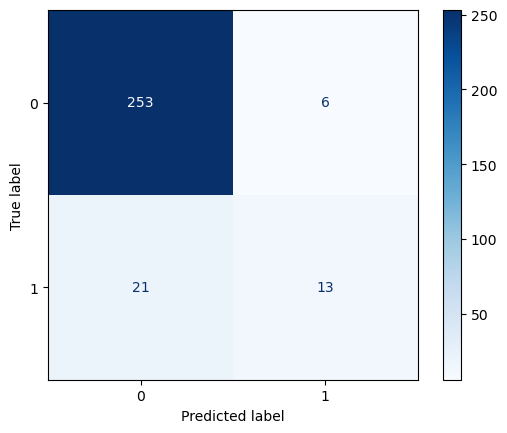

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

The model is really good at predicting non-draftees, as only 6 non-draftees out of 259 in the data set were correctly predicted. However, this model struggles with predicting WNBA draftees, as 21 of the 34 players in the dataset that got drafted were predicted to not get drafted, leading to a very low recall score. This might show that, especially in later rounds, WNBA teams are not necessarily looking for the best statistical players, but players that fit into the team's identity despite not having gaudy counting stats.

In [60]:
#Calculating draft probabilities for each eligible player
draft_probabilities = model.predict_proba(X)
draft_probabilities = draft_probabilities[:, 1]

In [61]:
#Creating new column in the original dataframe
df_stats["Draft Probability"] = draft_probabilities

In [62]:
#Sorting dataframe by draft probability
df_stats.sort_values(by = "Draft Probability", ascending = False).head(20)

,Drafted?,MPG,A/TO,TS%,2PVAL,3PVAL,USG%,PP40,ORP40,RP40,AP40,SP40,BP40,FP40,TP40,C,F,F-C,G-F,Draft Probability
Player,,,,,,,,,,,,,,,,,,,,
Lauren Betts,1,27.7,1.43,0.602,0.328,0.000,32.1,29.6,6.0,15.2,5.5,1.8,3.6,2.5,3.2,1,0,0,0,0.963522
Tonie Morgan,1,34.5,2.15,0.549,0.152,0.015,25.0,19.1,0.8,4.3,11.1,1.3,0.9,2.4,4.3,0,0,0,0,0.883214
Latasha Lattimore,1,26.3,0.50,0.552,0.164,0.013,23.5,19.8,4.1,11.3,1.9,1.1,3.8,2.1,3.2,0,1,0,0,0.824050
Olivia Miles,1,35.4,1.77,0.593,0.169,0.060,30.1,26.5,0.7,9.7,9.0,2.4,0.4,2.3,4.2,0,0,0,0,0.821874
Flau'jae Johnson,1,25.2,1.51,0.549,0.200,0.060,23.0,27.1,2.6,8.1,4.8,2.4,1.4,2.9,2.7,0,0,0,0,0.811272
Raegan Beers,0,24.7,0.99,0.632,0.327,0.005,30.2,30.6,6.6,20.1,4.3,1.7,2.0,4.2,3.7,1,0,0,0,0.777164
Payton Verhulst,0,30.9,1.75,0.507,0.125,0.058,19.0,18.7,2.7,8.5,4.7,2.3,1.4,2.2,2.2,0,0,0,0,0.739506
Taleyah Jones,0,34.2,0.69,0.581,0.155,0.079,21.0,24.0,2.5,6.0,2.8,1.7,0.7,1.4,3.3,0,0,0,0,0.730161
Azzi Fudd,1,28.6,2.10,0.608,0.128,0.106,22.7,26.6,1.1,4.0,4.8,3.9,0.7,1.1,2.1,0,0,0,0,0.719402


When calculating the draft probability for each draft-eligible player in the power conferences, the player with the highest probability was the eventual 4th overall pick, Lauren Betts. The 2nd overall pick, Olivia Miles, ranked 4th in the dataframe, while the 1st overall pick, Azzi Fudd, was 9th. Interestingly enough, the top 2 players that did not get drafted were both Oklahoma Sooners; neither Raegan Beers nor Payton Verhulst got selected. This may be pure chance, but, considering the fact that no Oklahoma players got drafted, this might suggest that WNBA scouts are glossing over Oklahoma, despite them finishing 26-8 overall and 11-5 in one of the toughest conferences, the SEC.

In [63]:
#Show WNBA draftees with the lowest draft probability
df_drafted = df_stats[df_stats["Drafted?"] == 1]
df_drafted.sort_values(by = "Draft Probability", ascending = True).head(20)

,Drafted?,MPG,A/TO,TS%,2PVAL,3PVAL,USG%,PP40,ORP40,RP40,AP40,SP40,BP40,FP40,TP40,C,F,F-C,G-F,Draft Probability
Player,,,,,,,,,,,,,,,,,,,,
Jordan Obi,1,26.2,0.54,0.560,0.153,0.006,21.4,16.4,4.3,11.0,1.9,0.9,1.1,3.6,3.0,0,0,0,0,0.047233
Taylor Bigby,1,26.0,1.35,0.592,0.040,0.071,14.1,15.2,0.8,4.2,2.0,1.3,0.3,1.9,1.3,0,0,0,0,0.049510
Indya Nivar,1,28.7,1.43,0.510,0.147,0.025,27.1,17.8,2.1,8.7,6.2,4.5,0.9,4.1,3.6,0,0,0,0,0.060073
Jessica Timmons,1,31.9,1.16,0.576,0.125,0.078,24.2,24.5,1.1,6.8,3.5,1.2,0.0,3.0,2.5,0,0,0,0,0.150244
Serah Williams,1,17.4,0.95,0.612,0.161,0.000,25.7,16.9,4.5,11.2,3.8,1.8,3.4,4.4,3.6,0,1,0,0,0.159424
Angela Dugalić,1,23.7,1.17,0.578,0.129,0.030,23.6,18.2,3.3,11.4,4.4,2.2,1.3,3.4,3.1,0,1,0,0,0.164119
Lani White,1,30.3,0.57,0.619,0.133,0.095,23.9,25.2,1.2,7.5,2.4,0.9,0.3,2.4,3.5,0,0,0,0,0.177245
Zee Spearman,1,26.3,0.40,0.458,0.154,0.038,24.4,18.6,5.4,10.6,1.8,1.5,2.3,4.3,3.7,0,1,0,0,0.237911
Gabriela Jaquez,1,30.4,1.11,0.653,0.133,0.042,20.5,21.3,2.8,8.6,3.2,1.8,0.2,2.5,2.4,0,0,0,0,0.266687


According to this model, Jordan Obi was the biggest surprise of this draft; the model predicted her to have a 4.72% chance of getting drafted, but she indeed went 44th overall to the Las Vegas Aces. The most egregious miss from the model, however, is Gabriela Jaquez, who, despite being given a 26.7% chance of being drafted, was selected 5th overall, the highest of anyone projected to not get drafted. This may be due to Jaquez constantly doing things on the floor that may not always show up in traditional boxscores, such as on-ball defense, diving on the floor for loose balls, and providing support for the true star of the national champion UCLA team, Lauren Betts. In fact, this list of top 20 "misses" also contains 3 other UCLA players: Angela Dugalić, Charlisse Leger-Walker, and Gianna Kneepkens; this shows that being a key contributor on a championship team often comes at the expense of individual statistics.

In [64]:
#For fun: project draft probability for future draftees
df_stats_full = pd.read_csv("data/stats_26.csv")
conferences = ["ACC", "BIG-12", "BIG10", "Big East", "SEC"]
df_stats_full = df_stats_full[df_stats_full["Conference"].isin(conferences)]
df_stats_full = df_stats_full.set_index(df_stats_full.columns[0])
df_stats_full = df_stats_full[["Drafted?", "POS", "MPG", "A/TO", "TS%", "2PVAL", "3PVAL", "USG%", "PP40", "ORP40", "RP40", "AP40", "SP40", "BP40", "FP40", "TP40"]]
df_stats_full.replace({'Y': 1, 'N': 0}, inplace=True)
dummies = pd.get_dummies(df_stats_full['POS'], dtype=int)
df_stats_full = pd.concat([df_stats_full, dummies], axis=1)
df_stats_full = df_stats_full.drop(columns = ["POS", "G"], axis = 1)
X_full = df_stats_full.drop(columns = ["Drafted?"], axis = 1)
draft_probabilities = model.predict_proba(X_full)
draft_probabilities = draft_probabilities[:, 1]
df_stats_full["Draft Probability"] = draft_probabilities
df_stats_full.sort_values(by = "Draft Probability", ascending = False).head(20)

/var/folders/s2/pcwbcsfd6px_q2f9yp2rxhhw0000gn/T/ipykernel_39561/3477816817.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_stats_full.replace({'Y': 1, 'N': 0}, inplace=True)


,Drafted?,MPG,A/TO,TS%,2PVAL,3PVAL,USG%,PP40,ORP40,RP40,AP40,SP40,BP40,FP40,TP40,C,F,F-C,G-F,Draft Probability
Player,,,,,,,,,,,,,,,,,,,,
Lauren Betts,1,27.7,1.43,0.602,0.328,0.000,32.1,29.6,6.0,15.2,5.5,1.8,3.6,2.5,3.2,1,0,0,0,0.963522
MiLaysia Fulwiley,0,22.7,1.48,0.566,0.230,0.059,29.1,30.8,1.9,7.6,7.5,6.0,3.0,3.9,4.2,0,0,0,0,0.962970
Mikayla Blakes,0,34.7,1.50,0.588,0.239,0.100,31.5,37.3,1.4,5.6,6.3,4.0,0.4,2.2,3.5,0,0,0,0,0.956274
Joyce Edwards,0,30.5,0.90,0.607,0.284,0.000,28.4,30.2,4.5,10.7,3.7,2.8,1.7,2.5,3.5,0,1,0,0,0.931706
Madison Francis,0,29.4,0.52,0.520,0.220,0.018,27.3,21.6,5.1,12.0,2.2,2.5,4.6,3.5,3.5,0,1,0,0,0.913383
Toby Fournier,0,29.1,0.55,0.564,0.266,0.015,30.1,28.6,4.5,13.1,2.0,1.5,3.6,3.3,3.1,0,1,0,0,0.911661
Sarah Strong,0,27.3,2.00,0.671,0.223,0.057,32.6,29.7,2.1,12.4,6.2,5.5,2.6,2.5,2.8,0,1,0,0,0.897317
Madison Booker,0,32.5,1.76,0.574,0.247,0.016,26.9,28.0,2.8,10.0,5.5,3.2,1.0,2.7,2.6,0,1,0,0,0.893581
Aaliyah Chavez,0,32.3,1.44,0.505,0.150,0.096,23.3,27.3,1.2,5.6,6.3,2.0,0.4,2.2,3.6,0,0,0,0,0.890280


Just for fun, I decided to run this model on future potential draftees in college basketball, and the player at the top (excluding Lauren Betts, who already got drafted) is MiLaysia Fulwiley. Fulwiley is an athletic guard who is not known as a three-point shooter, which is becoming a theme for this draft probability model; three-point specialists are less likely to receive high scores (except for Justine Pissott, for a reason I will explain later).

In [65]:
!pip install statsmodels

In [66]:
#Show p-values for each variable of the model
import statsmodels.api as sm

X_with_const = sm.add_constant(X)
model_sm = sm.Logit(y, X_with_const)
result = model_sm.fit()
print(result.summary())

         Current function value: 0.165281
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:               Drafted?   No. Observations:                  293
Model:                          Logit   Df Residuals:                      274
Method:                           MLE   Df Model:                           18
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.5396
Time:                        13:54:16   Log-Likelihood:                -48.427
converged:                      False   LL-Null:                       -105.18
Covariance Type:            nonrobust   LLR p-value:                 7.000e-16
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -16.1817      5.363     -3.017      0.003     -26.694      -5.670
MPG            0.2395      0.091      2.638      0.008       0.06

/Users/harperkates/miniconda3/envs/ds/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Thanks to the statsmodels package, we are able to view the p-values for each variable in the model, allowing us to take a more statistical approach. When looking at the highest absolute value z-scores, the top 3 variables in impact on the model are points per 40 minutes, blocks per 40 minutes, and assists per 40 minutes. These make up 3 essential skills in basketball: scoring, passing, and interior defense; the model approximates these three skills as translating the best to the WNBA. Also, the coefficient for the 3PVAL variable is smaller than the coefficient for the 2PVAL variable, explaining why the model values 2-point finishing over 3-point shooting. Finally, the coefficient for the G-F dummy variable is positive, which means that players listed as G-F are more likely to receive a higher score than players listed as G. This explains why Justine Pissott, who is listed as G-F, receives such a high score despite being a three-point specialist.